# Лабораторная работа №2
## Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Цель:** изучение способов предварительной обработки данных для дальнейшего формирования моделей.

**Датасет:** Titanic (Титаник) из библиотеки seaborn — содержит пропуски, категориальные и числовые признаки.

---

## 1. Описание набора данных

Датасет **Titanic** содержит информацию о пассажирах «Титаника» и используется для задачи бинарной классификации — предсказания выживания пассажира.

| Признак | Тип | Описание |
|---------|-----|----------|
| survived | int | Выжил (1) или нет (0) — целевая переменная |
| pclass | int | Класс каюты (1, 2, 3) |
| sex | str | Пол пассажира |
| age | float | Возраст (содержит пропуски) |
| sibsp | int | Кол-во братьев/сестёр/супругов на борту |
| parch | int | Кол-во родителей/детей на борту |
| fare | float | Стоимость билета |
| embarked | str | Порт посадки (C, Q, S) — содержит пропуски |
| class | str | Класс (First, Second, Third) |
| who | str | Мужчина, женщина, ребёнок |
| adult_male | bool | Взрослый мужчина |
| deck | str | Палуба (содержит много пропусков) |
| embark_town | str | Город посадки |
| alive | str | Выжил (yes/no) |
| alone | bool | Один ли на борту |

## 2. Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
)
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = sns.load_dataset('titanic')
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 3. Обработка пропусков в данных

### 3.1. Анализ пропусков

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_info = pd.DataFrame({
    'Пропуски': missing,
    '% пропусков': missing_pct
}).sort_values('Пропуски', ascending=False)

missing_info[missing_info['Пропуски'] > 0]

,Пропуски,% пропусков
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


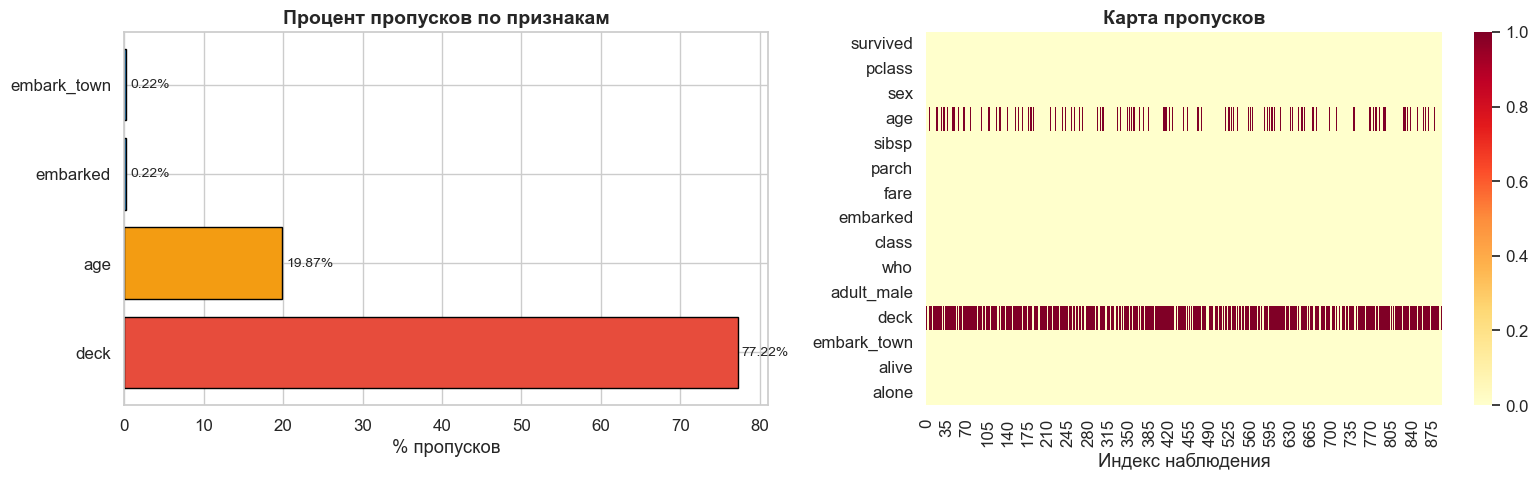

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cols_with_missing = missing_info[missing_info['Пропуски'] > 0]
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#3498db' for p in cols_with_missing['% пропусков']]
axes[0].barh(cols_with_missing.index, cols_with_missing['% пропусков'], color=colors, edgecolor='black')
axes[0].set_xlabel('% пропусков')
axes[0].set_title('Процент пропусков по признакам', fontsize=14, fontweight='bold')
for i, (idx, row) in enumerate(cols_with_missing.iterrows()):
    axes[0].text(row['% пропусков'] + 0.5, i, f"{row['% пропусков']}%", va='center', fontsize=10)

sns.heatmap(df.isnull().T, cbar=True, yticklabels=True, ax=axes[1], cmap='YlOrRd')
axes[1].set_title('Карта пропусков', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Индекс наблюдения')

plt.tight_layout()
plt.show()

### 3.2. Удаление столбцов с большим количеством пропусков

In [6]:
df_clean = df.drop(columns=['deck'])
df_clean.shape

(891, 14)

### 3.3. Заполнение пропусков в числовых признаках

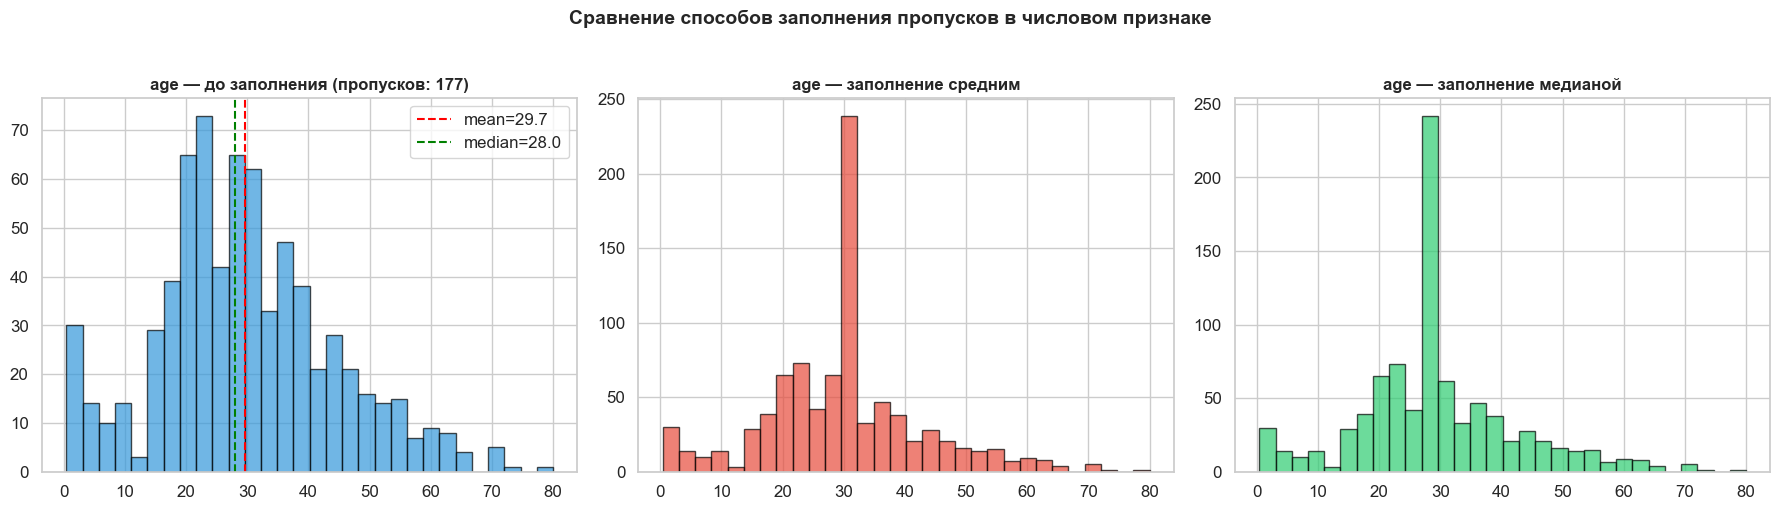

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_clean['age'].dropna(), bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title(f"age — до заполнения (пропусков: {df_clean['age'].isnull().sum()})", fontsize=12, fontweight='bold')
axes[0].axvline(df_clean['age'].mean(), color='red', linestyle='--', label=f"mean={df_clean['age'].mean():.1f}")
axes[0].axvline(df_clean['age'].median(), color='green', linestyle='--', label=f"median={df_clean['age'].median():.1f}")
axes[0].legend()

df_mean = df_clean.copy()
df_mean['age'] = df_mean['age'].fillna(df_mean['age'].mean())
axes[1].hist(df_mean['age'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title(f"age — заполнение средним", fontsize=12, fontweight='bold')

df_median = df_clean.copy()
df_median['age'] = df_median['age'].fillna(df_median['age'].median())
axes[2].hist(df_median['age'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[2].set_title(f"age — заполнение медианой", fontsize=12, fontweight='bold')

plt.suptitle('Сравнение способов заполнения пропусков в числовом признаке', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Заполнение age медианой по классу каюты
df_clean['age'] = df_clean.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)
df_clean.groupby('pclass')['age'].agg(['median', 'mean', 'count'])

,median,mean,count
pclass,,,
1,37.0,38.062130,216
2,29.0,29.825163,184
3,24.0,24.824684,491


### 3.4. Заполнение пропусков в категориальных признаках

In [9]:
df_clean['embarked'].value_counts(dropna=False)

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [10]:
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

df_clean['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

### 3.5. Использование SimpleImputer из sklearn

In [11]:
df_imputer_demo = df[['age', 'fare']].copy()

imputer_mean = SimpleImputer(strategy='mean')
df_imputed_mean = pd.DataFrame(
    imputer_mean.fit_transform(df_imputer_demo),
    columns=df_imputer_demo.columns
)

imputer_median = SimpleImputer(strategy='median')
df_imputed_median = pd.DataFrame(
    imputer_median.fit_transform(df_imputer_demo),
    columns=df_imputer_demo.columns
)

pd.DataFrame({
    'Пропуски до': df_imputer_demo.isnull().sum(),
    'Пропуски (mean)': df_imputed_mean.isnull().sum(),
    'Пропуски (median)': df_imputed_median.isnull().sum(),
})

,Пропуски до,Пропуски (mean),Пропуски (median)
age,177,0,0
fare,0,0,0


### 3.6. Итог обработки пропусков

In [12]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Series([], dtype: int64)

## 4. Кодирование категориальных признаков

### 4.1. Обзор категориальных признаков

In [13]:
cat_cols = df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
for col in cat_cols:
    print(f"{col}: {df_clean[col].nunique()} уникальных — {list(df_clean[col].unique()[:8])}")

sex: 2 уникальных — ['male', 'female']
embarked: 3 уникальных — ['S', 'C', 'Q']
class: 3 уникальных — ['Third', 'First', 'Second']
who: 3 уникальных — ['man', 'woman', 'child']
adult_male: 2 уникальных — [True, False]
embark_town: 3 уникальных — ['Southampton', 'Cherbourg', 'Queenstown']
alive: 2 уникальных — ['no', 'yes']
alone: 2 уникальных — [False, True]


### 4.2. Label Encoding (порядковое кодирование)

Подходит для **порядковых** (ordinal) признаков, где между категориями есть естественный порядок.

In [14]:
le = LabelEncoder()
df_encoded = df_clean.copy()
df_encoded['sex_le'] = le.fit_transform(df_encoded['sex'])

df_encoded[['sex', 'sex_le']].drop_duplicates()

,sex,sex_le
0,male,1
1,female,0


In [15]:
oe = OrdinalEncoder(categories=[['Third', 'Second', 'First']])
df_encoded['class_oe'] = oe.fit_transform(df_encoded[['class']])

df_encoded[['class', 'class_oe']].drop_duplicates()

,class,class_oe
0,Third,0.0
1,First,2.0
9,Second,1.0


### 4.3. One-Hot Encoding (бинарное кодирование)

Подходит для **номинальных** (nominal) признаков, где между категориями нет порядка.

In [16]:
df_onehot = pd.get_dummies(df_encoded, columns=['embarked'], prefix='embarked', dtype=int)

df_onehot[['embarked_C', 'embarked_Q', 'embarked_S']].head(8)

,embarked_C,embarked_Q,embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
5,0,1,0
6,0,0,1
7,0,0,1


In [17]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
embarked_encoded = ohe.fit_transform(df_encoded[['embarked']])
embarked_df = pd.DataFrame(embarked_encoded, columns=ohe.get_feature_names_out(['embarked']))

embarked_df.head(8)

,embarked_Q,embarked_S
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,1.0,0.0
6,0.0,1.0
7,0.0,1.0


### 4.4. Frequency Encoding

In [18]:
freq_map = df_encoded['embark_town'].value_counts(normalize=True)
df_encoded['embark_town_freq'] = df_encoded['embark_town'].map(freq_map)

df_encoded[['embark_town', 'embark_town_freq']].drop_duplicates()

,embark_town,embark_town_freq
0,Southampton,0.725028
1,Cherbourg,0.188552
5,Queenstown,0.086420


### 4.5. Визуализация результатов кодирования

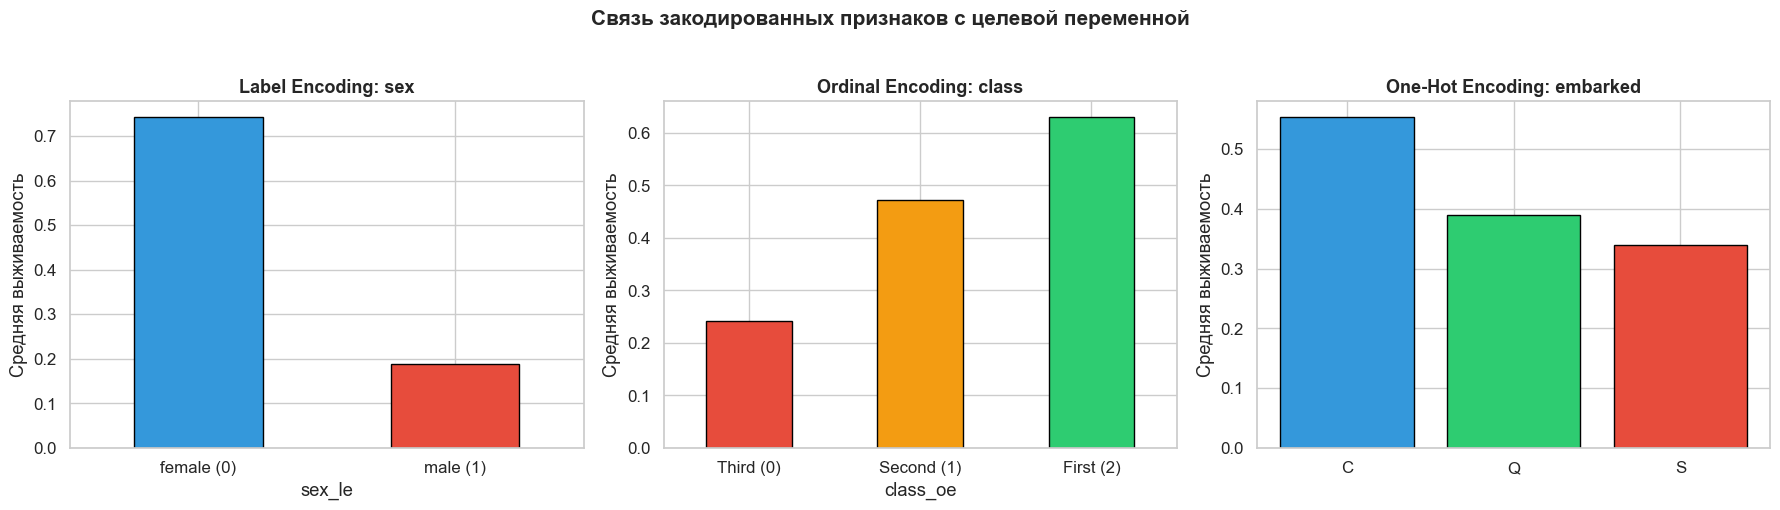

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
df_encoded.groupby('sex_le')['survived'].mean().plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title('Label Encoding: sex', fontsize=13, fontweight='bold')
ax.set_xticklabels(['female (0)', 'male (1)'], rotation=0)
ax.set_ylabel('Средняя выживаемость')

ax = axes[1]
df_encoded.groupby('class_oe')['survived'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
ax.set_title('Ordinal Encoding: class', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Third (0)', 'Second (1)', 'First (2)'], rotation=0)
ax.set_ylabel('Средняя выживаемость')

ax = axes[2]
colors_emb = ['#3498db', '#2ecc71', '#e74c3c']
for col, color in zip(['embarked_C', 'embarked_Q', 'embarked_S'], colors_emb):
    mean_survived = df_onehot[df_onehot[col] == 1]['survived'].mean()
    ax.bar(col.replace('embarked_', ''), mean_survived, color=color, edgecolor='black')
ax.set_title('One-Hot Encoding: embarked', fontsize=13, fontweight='bold')
ax.set_ylabel('Средняя выживаемость')

plt.suptitle('Связь закодированных признаков с целевой переменной', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Масштабирование данных

### 5.1. Обзор числовых признаков до масштабирования

In [20]:
num_cols = ['age', 'fare', 'sibsp', 'parch']
df_clean[num_cols].describe().T.style.format("{:.2f}").background_gradient(cmap='YlOrRd', axis=1)

,count,mean,std,min,25%,50%,75%,max
age,891.00,29.07,13.24,0.42,22.00,26.00,37.00,80.00
fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33
sibsp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00
parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00


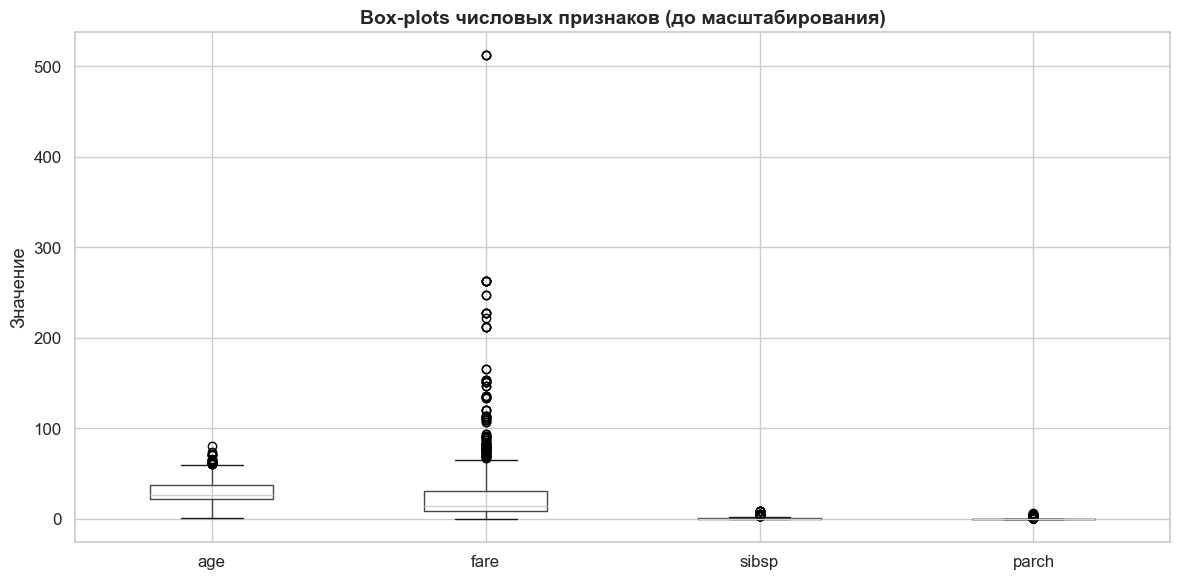

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
df_clean[num_cols].boxplot(ax=ax)
ax.set_title('Box-plots числовых признаков (до масштабирования)', fontsize=14, fontweight='bold')
ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()

### 5.2. StandardScaler (Z-нормализация)

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

In [22]:
scaler_standard = StandardScaler()
df_standard = pd.DataFrame(
    scaler_standard.fit_transform(df_clean[num_cols]),
    columns=[f'{c}_std' for c in num_cols],
    index=df_clean.index
)
df_standard.describe().T.style.format("{:.4f}")

,count,mean,std,min,25%,50%,75%,max
age_std,891.0000,0.0000,1.0006,-2.1641,-0.5338,-0.2317,0.5993,3.8478
fare_std,891.0000,0.0000,1.0006,-0.6484,-0.4891,-0.3574,-0.0242,9.6672
sibsp_std,891.0000,0.0000,1.0006,-0.4745,-0.4745,-0.4745,0.4328,6.7842
parch_std,891.0000,0.0000,1.0006,-0.4737,-0.4737,-0.4737,-0.4737,6.9741


### 5.3. MinMaxScaler (нормализация в [0, 1])

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

In [23]:
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df_clean[num_cols]),
    columns=[f'{c}_minmax' for c in num_cols],
    index=df_clean.index
)
df_minmax.describe().T.style.format("{:.4f}")

,count,mean,std,min,25%,50%,75%,max
age_minmax,891.0000,0.3600,0.1664,0.0000,0.2712,0.3214,0.4597,1.0000
fare_minmax,891.0000,0.0629,0.0970,0.0000,0.0154,0.0282,0.0605,1.0000
sibsp_minmax,891.0000,0.0654,0.1378,0.0000,0.0000,0.0000,0.1250,1.0000
parch_minmax,891.0000,0.0636,0.1343,0.0000,0.0000,0.0000,0.0000,1.0000


### 5.4. RobustScaler (устойчив к выбросам)

$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1}$$

In [24]:
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(
    scaler_robust.fit_transform(df_clean[num_cols]),
    columns=[f'{c}_robust' for c in num_cols],
    index=df_clean.index
)
df_robust.describe().T.style.format("{:.4f}")

,count,mean,std,min,25%,50%,75%,max
age_robust,891.0000,0.2044,0.8830,-1.7053,-0.2667,0.0000,0.7333,3.6000
fare_robust,891.0000,0.7687,2.1522,-0.6260,-0.2834,0.0000,0.7166,21.5627
sibsp_robust,891.0000,0.5230,1.1027,0.0000,0.0000,0.0000,1.0000,8.0000
parch_robust,891.0000,0.3816,0.8061,0.0000,0.0000,0.0000,0.0000,6.0000


### 5.5. MaxAbsScaler (масштабирование в [-1, 1])

$$x_{scaled} = \frac{x}{|x_{max}|}$$

In [25]:
scaler_maxabs = MaxAbsScaler()
df_maxabs = pd.DataFrame(
    scaler_maxabs.fit_transform(df_clean[num_cols]),
    columns=[f'{c}_maxabs' for c in num_cols],
    index=df_clean.index
)
df_maxabs.describe().T.style.format("{:.4f}")

,count,mean,std,min,25%,50%,75%,max
age_maxabs,891.0000,0.3633,0.1656,0.0052,0.2750,0.3250,0.4625,1.0000
fare_maxabs,891.0000,0.0629,0.0970,0.0000,0.0154,0.0282,0.0605,1.0000
sibsp_maxabs,891.0000,0.0654,0.1378,0.0000,0.0000,0.0000,0.1250,1.0000
parch_maxabs,891.0000,0.0636,0.1343,0.0000,0.0000,0.0000,0.0000,1.0000


### 5.6. Сравнительная визуализация методов масштабирования

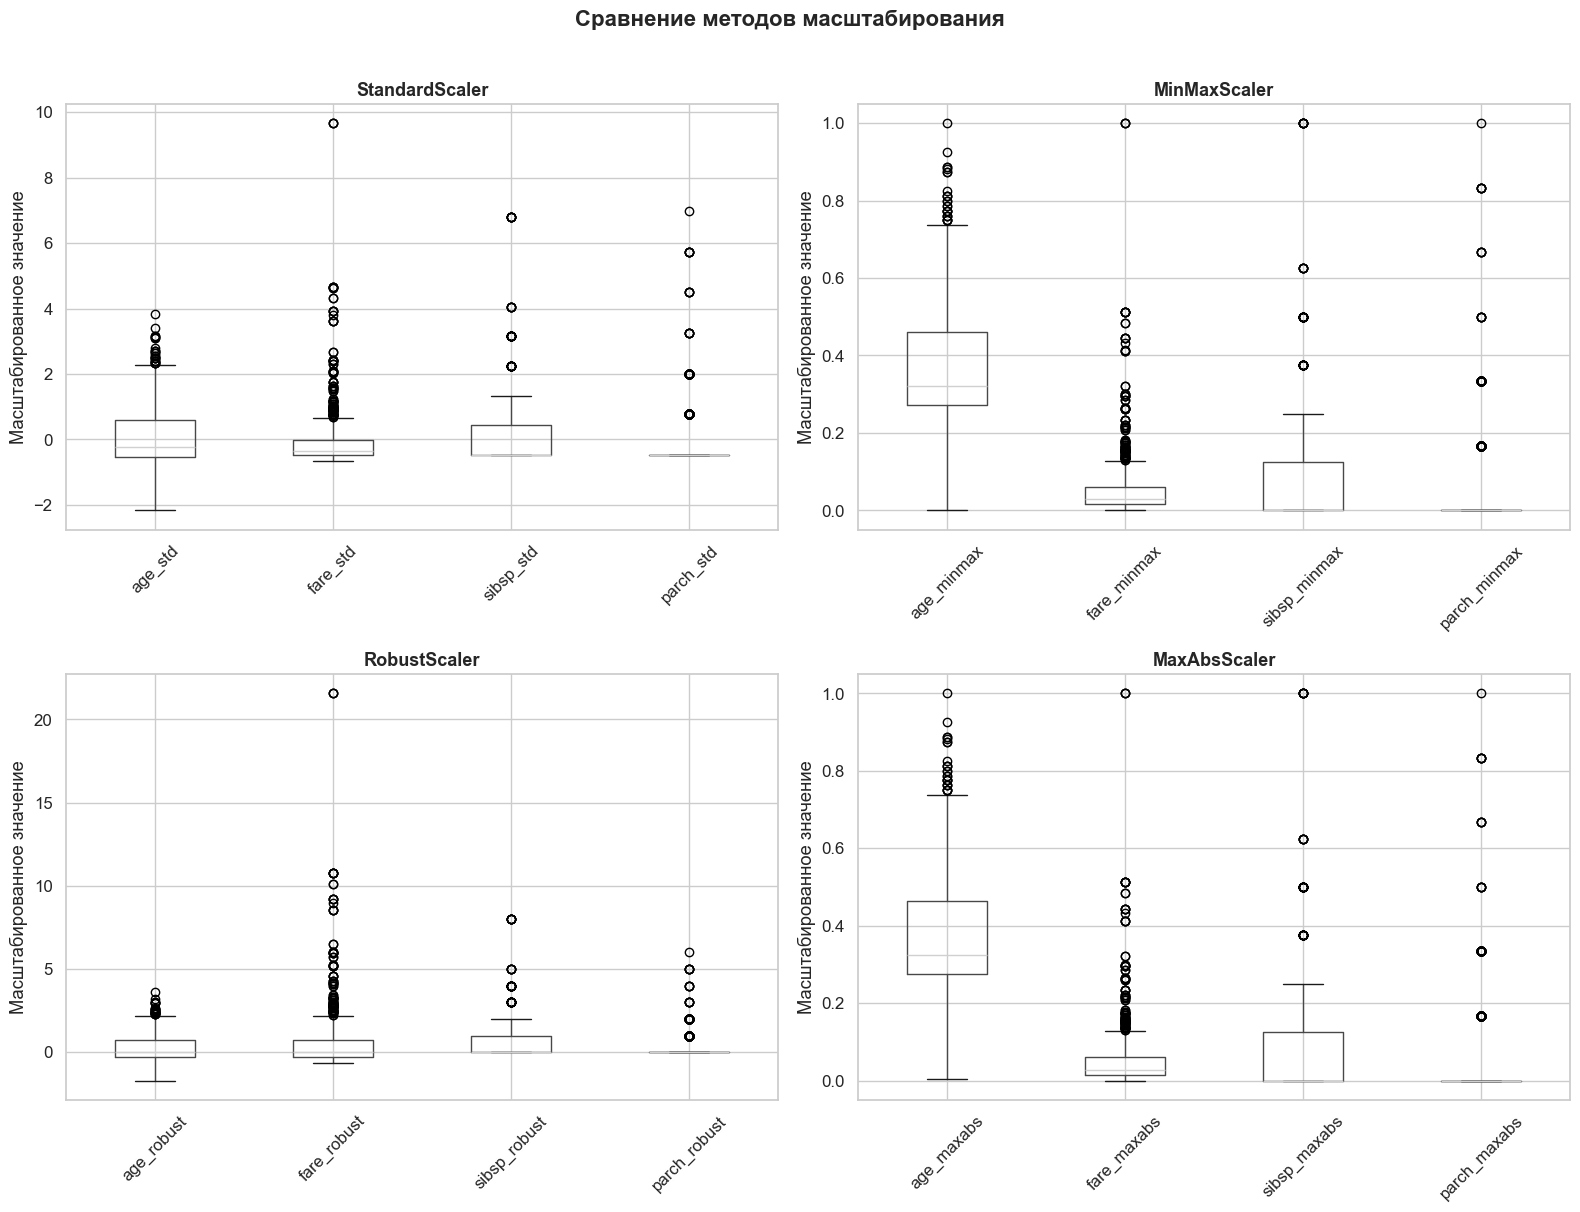

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scalers = {
    'StandardScaler': df_standard,
    'MinMaxScaler': df_minmax,
    'RobustScaler': df_robust,
    'MaxAbsScaler': df_maxabs
}

for ax, (name, scaled_df) in zip(axes.flatten(), scalers.items()):
    scaled_df.boxplot(ax=ax)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Масштабированное значение')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Сравнение методов масштабирования', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

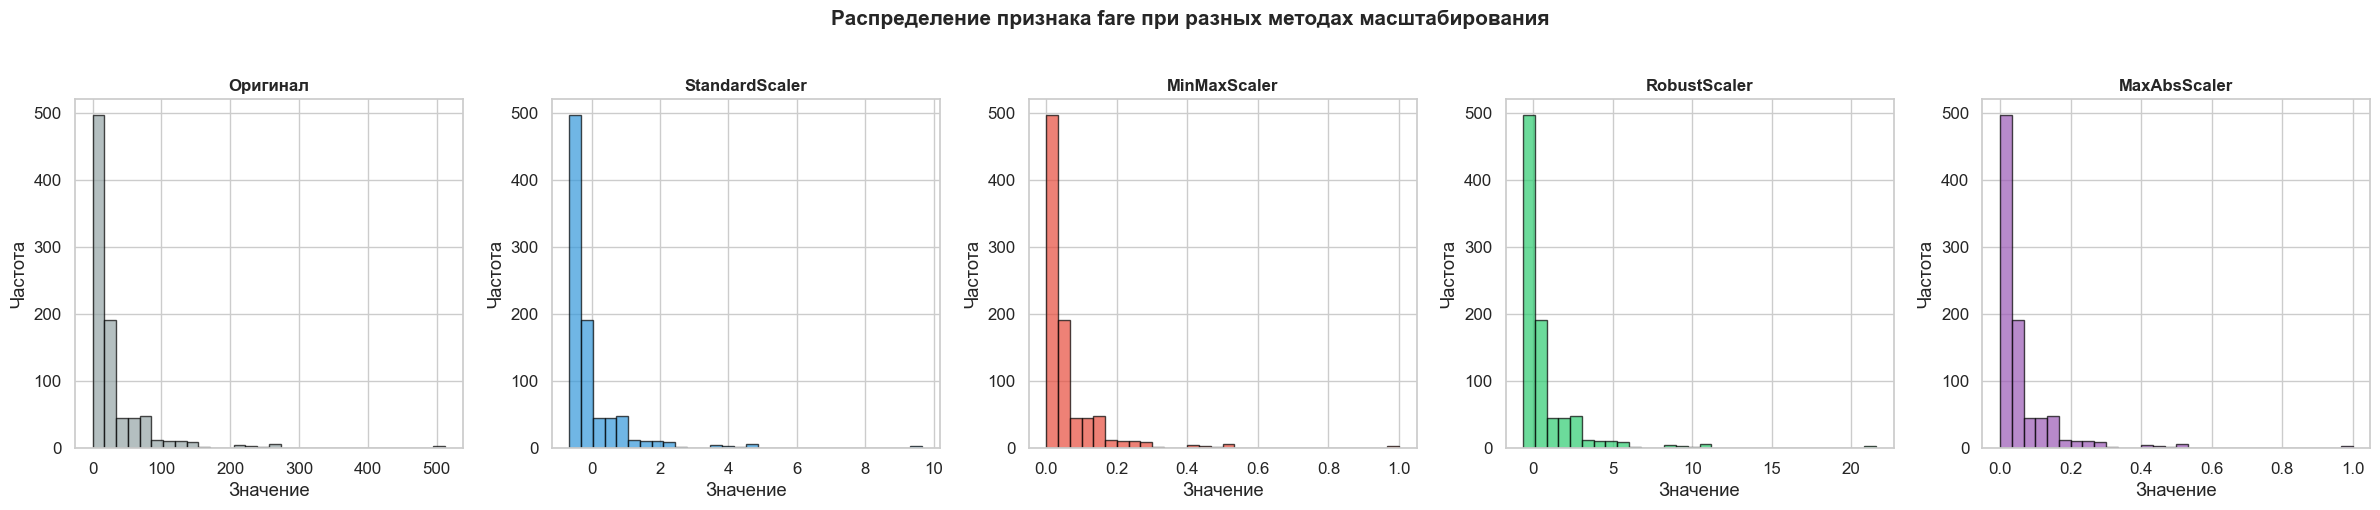

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

colors_hist = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

datasets = {
    'Оригинал': df_clean['fare'],
    'StandardScaler': df_standard['fare_std'],
    'MinMaxScaler': df_minmax['fare_minmax'],
    'RobustScaler': df_robust['fare_robust'],
    'MaxAbsScaler': df_maxabs['fare_maxabs'],
}

for ax, (name, data), color in zip(axes, datasets.items(), colors_hist):
    ax.hist(data, bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')

fig.suptitle('Распределение признака fare при разных методах масштабирования',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.7. Сводная таблица сравнения методов масштабирования

In [28]:
comparison = pd.DataFrame({
    'Метод': ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'MaxAbsScaler'],
    'Формула': ['(x - μ) / σ', '(x - min) / (max - min)', '(x - Q2) / (Q3 - Q1)', 'x / |max|'],
    'Диапазон': ['(-∞, +∞)', '[0, 1]', '(-∞, +∞)', '[-1, 1]'],
    'Среднее → 0': ['Да', 'Нет', '≈ Нет', 'Нет'],
    'Устойч. к выбросам': ['Нет', 'Нет', 'Да', 'Нет'],
    'Когда использовать': [
        'Нормальное распределение',
        'Ограниченный диапазон нужен',
        'Есть выбросы',
        'Разреженные данные'
    ]
})

comparison.style.set_properties(**{'text-align': 'center'}).hide(axis='index')

Метод,Формула,Диапазон,Среднее → 0,Устойч. к выбросам,Когда использовать
StandardScaler,(x - μ) / σ,"(-∞, +∞)",Да,Нет,Нормальное распределение
MinMaxScaler,(x - min) / (max - min),"[0, 1]",Нет,Нет,Ограниченный диапазон нужен
RobustScaler,(x - Q2) / (Q3 - Q1),"(-∞, +∞)",≈ Нет,Да,Есть выбросы
MaxAbsScaler,x / |max|,"[-1, 1]",Нет,Нет,Разреженные данные


## 6. Выводы

### Обработка пропусков
- Столбец `deck` с 77% пропусков удалён.
- Числовой признак `age` заполнен медианой по классу каюты.
- Категориальные признаки `embarked` и `embark_town` заполнены модой.

### Кодирование категориальных признаков
- **Label Encoding** — для бинарных признаков (`sex`).
- **Ordinal Encoding** — для порядковых признаков (`class`).
- **One-Hot Encoding** — для номинальных признаков (`embarked`).
- **Frequency Encoding** — замена категории её частотой.

### Масштабирование данных
- **StandardScaler** — среднее 0, стд. отклонение 1. Для нормально распределённых данных.
- **MinMaxScaler** — диапазон [0, 1]. Когда нужен ограниченный диапазон.
- **RobustScaler** — использует медиану и IQR. Устойчив к выбросам.
- **MaxAbsScaler** — масштабирует по max абсолютному значению. Для разреженных данных.